In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch

plt.style.use("dark_background")
np.random.seed(0)
torch.manual_seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COLORMAP = cm.magma


# 1. Diffusion: The Forward Process

Having established the physics of diffusion, we will now put this into practice in the context of machine learning. The two cells below contain an exercise to visualize the forward (annealing) process, defined by the equations we saw in class. The forward process is defined by
$$\begin{equation} d\mathbf{x} = \mathbf{f}(\mathbf{x},t)dt + g(t)d\mathbf{w},\tag{1}\end{equation}$$
where $\mathbf{w}$ is the Weiner process, $\mathbf{f}(\mathbf{x},t)$ is the **drift** coefficient, and $g(t)$ is the **diffusion** coefficient. For a variance-exploding stochastic differential equation, (VE SDE), the drift coefficient is zero, and the diffusion coeffcient is defined by
$$\begin{equation} g(t) = \sqrt{\frac{d\sigma(t)}{dt}}, \tag{2} \end{equation}$$
where $\sigma(t)$ is the noise schedule. In Song et al, 2020, $\sigma(t)$ is defined as $\sigma(t) = \sigma_{\text{min}}\left(\frac{\sigma_{\text{max}}}{\sigma_{\text{min}}}\right)^t$.

The relevant functions for the forward prcess are defined below.

In [3]:
# --- Diffusion settings (VE SDE) ---
import math

sigma_min = 0.01
sigma_max = 2.0


def to_tensor(x, device=None, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        if device is not None:
            return x.to(device=device, dtype=dtype)
        return x.to(dtype=dtype)
    return torch.tensor(x, device=device or DEVICE, dtype=dtype)


def sigma_t(t):
    # Log-linear schedule from Song et al. (VE SDE). This is the perturbation scale at time t.
    t = to_tensor(t)
    return sigma_min * (sigma_max / sigma_min) ** t


def g_t(t):
    # g(t) for VE SDE: g(t) = sigma(t) * sqrt(2 * log(sigma_max/sigma_min))
    t = to_tensor(t)
    log_ratio = math.log(sigma_max / sigma_min)
    return sigma_t(t) * math.sqrt(2.0 * log_ratio)


def mixture_params_from_widgets(n, means_x, means_y, stds, device=DEVICE, dtype=torch.float32):
    params = []
    for i in range(n):
        mu = torch.tensor([means_x[i], means_y[i]], device=device, dtype=dtype)
        s = torch.tensor(stds[i], device=device, dtype=dtype)
        params.append((mu, s))
    return params


def _stack_params(params, device, dtype):
    mus = torch.stack([p[0] for p in params], dim=0).to(device=device, dtype=dtype)  # (K,2)
    stds = torch.stack([p[1] for p in params], dim=0).to(device=device, dtype=dtype)  # (K,)
    return mus, stds


def _expand_t(t, batch, device, dtype):
    t = to_tensor(t, device=device, dtype=dtype)
    if t.ndim == 0:
        t = t.repeat(batch)
    elif t.shape[0] != batch:
        t = t.expand(batch)
    return t


def mixture_pdf(grid_xy, params, t):
    # grid_xy: (..., 2) torch tensor
    device = grid_xy.device
    dtype = grid_xy.dtype
    grid_flat = grid_xy.view(-1, 2)
    batch = grid_flat.shape[0]

    t = _expand_t(t, batch, device, dtype)
    sig = sigma_t(t)  # (B,)

    mus, stds = _stack_params(params, device, dtype)
    var = stds[None, :] ** 2 + sig[:, None] ** 2  # (B, K)
    diff = grid_flat[:, None, :] - mus[None, :, :]  # (B, K, 2)

    exponent = -0.5 * (diff ** 2).sum(-1) / var
    norm = 1.0 / (2.0 * torch.pi * var)
    comps = norm * torch.exp(exponent)
    pdf = comps.mean(dim=1)
    return pdf.view(*grid_xy.shape[:-1])


def mixture_score(x, params, t):
    # Analytic score: grad_x log p_t(x) for Gaussian mixture
    device = x.device
    dtype = x.dtype
    x_flat = x.view(-1, 2)
    batch = x_flat.shape[0]

    t = _expand_t(t, batch, device, dtype)
    sig = sigma_t(t)  # (B,)

    mus, stds = _stack_params(params, device, dtype)
    var = stds[None, :] ** 2 + sig[:, None] ** 2  # (B, K)
    diff = x_flat[:, None, :] - mus[None, :, :]  # (B, K, 2)

    exponent = -0.5 * (diff ** 2).sum(-1) / var
    norm = 1.0 / (2.0 * torch.pi * var)
    comps = norm * torch.exp(exponent)
    post = comps / (comps.sum(dim=1, keepdim=True) + 1e-12)

    comp_score = -diff / var[..., None]
    score = (post[..., None] * comp_score).sum(dim=1)
    return score.view(*x.shape)


def sample_from_mixture(params, t, n_samples=1000, device=DEVICE, dtype=torch.float32):
    t = to_tensor(t, device=device, dtype=dtype)
    if t.ndim != 0:
        t = t.view(-1)[0]
    sig = sigma_t(t)

    K = len(params)
    weights = torch.ones(K, device=device, dtype=dtype) / K
    comps = torch.distributions.Categorical(weights).sample((n_samples,))
    x = torch.empty((n_samples, 2), device=device, dtype=dtype)

    for k in range(K):
        idx = comps == k
        if idx.any():
            mu, s = params[k]
            var = s ** 2 + sig ** 2
            x[idx] = mu + torch.randn((idx.sum(), 2), device=device, dtype=dtype) * torch.sqrt(var)
    return x


def visualize_distribution(params, t=0.0, grid_lim=6, levels=30, cmap=COLORMAP):
    xs = torch.linspace(-grid_lim, grid_lim, 200, device=DEVICE)
    ys = torch.linspace(-grid_lim, grid_lim, 200, device=DEVICE)
    X, Y = torch.meshgrid(xs, ys, indexing='xy')
    grid = torch.stack([X, Y], dim=-1)
    Z = mixture_pdf(grid, params, t)

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), Z.cpu().numpy(), levels=levels, cmap=cmap)
    ax.set_title(f'Target distribution (at t={t:.2f})')
    ax.set_xlim(-grid_lim, grid_lim)
    ax.set_ylim(-grid_lim, grid_lim)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

    return grid


def true_score(t, x, params):
    return mixture_score(x, params, t)


We can now play around with the forward process by choosing a ground truth distribution and annealing it according to equation 1. We'll use a simple mixture of Gaussians, because we can analytically calculate the score of a Gaussian (more on this in the reverse process section).

In the cell below, choose the number of Gaussian blobs you want in your mixture and the means and standard deviations of each. You'll see how the distribution gets annealed gradually until the modes can no longer be resolved ($t=1$).

In [4]:
# Widgets for blob parameters
max_blobs = 4
n_blobs = widgets.IntSlider(value=2, min=1, max=max_blobs, step=1, description='n_blobs')

means_x = [widgets.FloatSlider(value=-2 + i*2, min=-5, max=5, step=0.1, description=f'mu_x{i+1}') for i in range(max_blobs)]
means_y = [widgets.FloatSlider(value=0 + (i%2)*2, min=-5, max=5, step=0.1, description=f'mu_y{i+1}') for i in range(max_blobs)]
stds = [widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.05, description=f'std{i+1}') for i in range(max_blobs)]

t_mid = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, description='t_mid')


def update_forward(n_blobs, t_mid, **kwargs):
    mx = [kwargs[f'mx{i}'] for i in range(max_blobs)]
    my = [kwargs[f'my{i}'] for i in range(max_blobs)]
    ss = [kwargs[f's{i}'] for i in range(max_blobs)]
    params = mixture_params_from_widgets(n_blobs, mx, my, ss)

    grid_lim = 6
    xs = torch.linspace(-grid_lim, grid_lim, 200, device=DEVICE)
    ys = torch.linspace(-grid_lim, grid_lim, 200, device=DEVICE)
    X, Y = torch.meshgrid(xs, ys, indexing='xy')
    grid = torch.stack([X, Y], dim=-1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, tt, title in zip(axes, [0.0, t_mid, 1.0], ['t=0', 't=mid', 't=1']):
        Z = mixture_pdf(grid, params, tt)
        ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), Z.cpu().numpy(), levels=30, cmap=COLORMAP)
        ax.set_title(title)
        ax.set_xlim(-grid_lim, grid_lim)
        ax.set_ylim(-grid_lim, grid_lim)
        ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


# Wire widgets
controls = {
    'n_blobs': n_blobs,
    't_mid': t_mid,
}
for i in range(max_blobs):
    controls[f'mx{i}'] = means_x[i]
    controls[f'my{i}'] = means_y[i]
    controls[f's{i}'] = stds[i]

out = widgets.interactive_output(update_forward, controls)

param_box = widgets.VBox([n_blobs, t_mid])
blob_box = widgets.VBox([
    widgets.HBox([means_x[i], means_y[i], stds[i]]) for i in range(max_blobs)
])

display(widgets.VBox([param_box, blob_box, out]))


# 2. Diffusion: The Reverse Process

Now that we have annealed our Gaussian mixture, we can reverse the process using the **Anderson formula** that we saw in class. This is
$$\begin{equation} d\mathbf{x} = [\mathbf{f}(\mathbf{x},t) - g^2(t)\nabla_\mathbf{x}\log p_t(\mathbf{x})]dt + g(t)d\mathbf{\bar{w}}, \tag{3}\end{equation}$$
where $\mathbf{\bar{w}}$ is the standard Wiener process when time flows backwards from $T$ to $0$. The gradient of the log of $p_t(\mathbf{x})$ is the **score** -- this is what guides the diffusion process back to the modes within the original distribution. Below, we calculate the score **analytically** -- this is not always possible, because often the distribution we are interested is unknown or cannot be written analytically! This is why we need neural networks.

Below is a visualization of the reverse process. We start sampling at $t=1$ (from the annealed distribution we generated earlier). At each step in time backwards, we calculate the score, which is then used to guide the sample to the true distribution. Play around with the visualization of the recovered distribution at different timesteps. You should see that the original multi-modal distribution is recovered at zero temperature (and that the resolution increases as you increase the number of samples). A plot of sample trajectories shows a few samples and how they were guided to the modes of the original distribution using the scores.

In [5]:
# Reverse diffusion simulation
reverse_state = {'traj': None, 'ts': None, 'params': None, 'samples': None, 'all_samples': []}

plot_out = widgets.Output()

t_mid_rev = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, description='t_mid')
resample_btn = widgets.Button(description='Resample')


def simulate_reverse(params, n_samples=100000, n_steps=200, device=DEVICE):
    # Start from x_1 ~ p_{t=1}
    x = sample_from_mixture(params, t=1.0, n_samples=n_samples, device=device)
    traj = [x.detach().cpu()]
    ts = [1.0]

    dt = -1.0 / n_steps
    sqrt_dt = math.sqrt(-dt)

    # Euler-Maruyama integration of reverse SDE
    for k in range(n_steps):
        t = 1.0 + k * dt  # decreasing
        g = g_t(t)
        score = mixture_score(x, params, t)
        noise = torch.randn_like(x)
        x = x + (-g ** 2) * score * dt + g * sqrt_dt * noise

        if (k + 1) % 5 == 0:
            traj.append(x.detach().cpu())
            ts.append(t + dt)

    traj = torch.stack(traj, dim=0)
    ts = torch.tensor(ts)
    return traj, ts


def update_reverse_plot(t_mid, **kwargs):
    if reverse_state['traj'] is None:
        return

    with plot_out:
        clear_output(wait=True)

        traj = reverse_state['traj']  # (T, B, 2) on CPU
        ts = reverse_state['ts']

        idx_mid = torch.argmin(torch.abs(ts - t_mid)).item()

        fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
        titles = ['t=1 (start)', f't={ts[idx_mid]:.2f}', 't=0 (end)']
        data = [traj[0], traj[idx_mid], traj[-1]]

        grid_lim = 6
        bins = 60
        for ax, title, pts in zip(axes, titles, data):
            pts_np = pts.numpy()
            ax.hist2d(pts_np[:, 0], pts_np[:, 1], bins=bins, range=[[-grid_lim, grid_lim], [-grid_lim, grid_lim]], cmap=COLORMAP)
            ax.set_title(title)
            ax.set_xlim(-grid_lim, grid_lim)
            ax.set_ylim(-grid_lim, grid_lim)
            ax.set_aspect('equal')
            plt.tight_layout()
        plt.show()

        # Trajectory visualization for a subset of samples with ground-truth overlay
        fig, ax = plt.subplots(1, 1, figsize=(4, 4))
        n_traj = 10
        total = traj.shape[1]
        idxs = np.linspace(0, total - 1, n_traj, dtype=int)

        params = reverse_state.get('params', None)
        if params is not None:
            xs = torch.linspace(-grid_lim, grid_lim, 200, device=DEVICE)
            ys = torch.linspace(-grid_lim, grid_lim, 200, device=DEVICE)
            X, Y = torch.meshgrid(xs, ys, indexing='xy')
            grid = torch.stack([X, Y], dim=-1)
            Z = mixture_pdf(grid, params, t=0.0)
            ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), Z.cpu().numpy(), levels=30, cmap=COLORMAP, alpha=0.25)

            # Analytical score field at t=0 (vectors)
            step = 12
            Xq = X[::step, ::step]
            Yq = Y[::step, ::step]
            grid_q = torch.stack([Xq, Yq], dim=-1)
            score_q = mixture_score(grid_q, params, t=0.0).cpu().numpy()
            ax.quiver(Xq.cpu().numpy(), Yq.cpu().numpy(), score_q[..., 0], score_q[..., 1],
                      color='white', alpha=0.55, width=0.003, scale=30)

        colors = plt.cm.tab10(np.linspace(0, 1, n_traj))
        traj_np = traj.numpy()
        for c, j in zip(colors, idxs):
            path = traj_np[:, j, :]
            ax.plot(path[:, 0], path[:, 1], alpha=0.9, linewidth=1.2, color=c)
            ax.scatter(path[0, 0], path[0, 1], s=14, marker='o', color=c, edgecolors='none')
            ax.scatter(path[-1, 0], path[-1, 1], s=18, marker='x', color=c)
        ax.set_title('Sample Trajectories (t=1 -> t=0)')
        ax.set_xlim(-grid_lim, grid_lim)
        ax.set_ylim(-grid_lim, grid_lim)
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()


def do_resample(_):
    mx = [means_x[i].value for i in range(max_blobs)]
    my = [means_y[i].value for i in range(max_blobs)]
    ss = [stds[i].value for i in range(max_blobs)]
    params = mixture_params_from_widgets(n_blobs.value, mx, my, ss)

    traj, ts = simulate_reverse(params)
    reverse_state['traj'] = traj
    reverse_state['ts'] = ts
    reverse_state['params'] = params
    reverse_state['samples'] = traj[-1].numpy()
    reverse_state['all_samples'].append(traj[-1].numpy())
    update_reverse_plot(t_mid_rev.value)


resample_btn.on_click(do_resample)

display(widgets.VBox([widgets.HBox([t_mid_rev, resample_btn]), plot_out]))

t_mid_rev.observe(lambda change: update_reverse_plot(change['new']), names='value')

# Initial run
do_resample(None)


# 3. Denoising Score Matching

In the above example, we worked with a 2D image whose distribution can be written in an analytical form (a Gaussian mixture). This allowed us to calculate the scores $\nabla_x \log{p(x)}$ analytically.

But suppose instead you are interested in doing inference on images of galaxies. The image space of galaxies has its own probability density, but the form of it is unknown. You cannot calculate the scores analytically because you do not have a functional form for $p(x)$. This is where **machine learning** can come in handy!  

You can train a neural network to learn the score of the distribution through diffusion. Denoising score matching (DSM), estimates the score at each noise scale (at each temperature). The model can have any architecture you like -- the key is that during training, the model perturbs the data gradually and learns to minimize the squared distance between the scores computed by the model $\mathbf{s}_\theta(\mathbf{x}_t,t)$ and the scores of the noise perturbation kernel $p(\mathbf{x}_t | \mathbf{x}_0)$.

## Training a model to learn the score using DSM
The **perturbation kernel** defines how the data will be annealed in the forward process. This is usually Gaussian, and so the perturbation looks like
$$\begin{equation}p(\mathbf{x}_t | \mathbf{x}_0) = N(\mathbf{x}_t|\mu(t)\mathbf{x}_0,\sigma^2(t)\mathbb{I})\tag{4}\end{equation}$$
where $\sigma(t)$ and $\mu(t)$ denote the standard deviation and mean respectively, as a function of the temperature. This perturbation kernel progressively perturbs the data in the forward process.

The kernel is used to train a neural network, which we define by $\mathbf{s}_\theta(\mathbf{x}t,t)$ (where $\theta$ refers to the parameters of the model), to approximate the score of the distribution using the following objective function:
$$\begin{equation}L_\theta = \mathbb{E}_{t\sim U(0,1)}\mathbb{E}_{\mathbf{x}_0\sim p(\mathbf{x}_0)} \mathbb{E}_{\mathbf{x}_t\sim p(\mathbf{x}_t|\mathbf{x}_0)} \left[\lambda(t)||\mathbf{s}_\theta(\mathbf{x}_t,t) - \nabla_{\mathbf{x}_t}\log p(\mathbf{x}_t|\mathbf{x}_0)||_2^2\right],\tag{5}\end{equation}$$
where $\lambda(t)$ is a time-dependent weighting factor, equal to the variance of the perturbation kernel. Minimizing this loss is the objective of the neural network during training; the model has converged (aka the scores have been learned) once the loss plateaus over time.

After training, we can use any sampling algorithm (like the Euler-Murayama algorithm used earlier) to sample from the perturbed distribution and reverse the diffusion process using the learned scores. That is, we use the learned scores to solve the reverse diffusion equation, Anderson's formula (equation 3), to generate new samples from the data distribution. Rather than learning the probability density of the data-generating process, which is often intractable because we have finite-sized datasets, learning the gradient of the log of the density (the score) is much more tractable and still allows us to generate samples that come from the true distribution of the data.

In the cell below, we will use the $\texttt{score-models}$ package to train a neural network on samples from our 2D Gaussian mixture and then sample from it to show that we can numerically learn the scores!

In [6]:
!pip install score-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 2.6 MB/s eta 0:00:00


In [7]:
import torch
import torch.distributions as tfd
import matplotlib.cm as cm
from matplotlib.colors import Normalize

class Dataset(torch.utils.data.Dataset):
    def __init__(self, distribution, size=2000, device=DEVICE):
        self.distribution = distribution
        self.size = size
        self.device = device

    def __len__(self):
        return self.size

    def __getitem__(self, index):
        return self.distribution.sample([1]).to(self.device).view(-1)


def make_torch_mixture(params, t=0.0, device=DEVICE):
    """
    params: list of (mu, std) from mixture_params_from_widgets
    t: diffusion time (adds sigma_t(t) noise)
    Returns: torch.distributions.MixtureSameFamily
    """
    K = len(params)
    mus = torch.stack([p[0] for p in params], dim=0).to(device=device, dtype=torch.float32)  # (K, 2)
    stds = torch.stack([p[1] for p in params], dim=0).to(device=device, dtype=torch.float32)  # (K,)
    sig = sigma_t(t).to(device=device, dtype=torch.float32)
    scales = torch.sqrt(stds ** 2 + sig ** 2)  # (K,)

    comp = tfd.Independent(tfd.Normal(loc=mus, scale=scales[:, None]), 1)
    mix = tfd.Categorical(probs=torch.ones(K, device=device) / K)
    return tfd.MixtureSameFamily(mix, comp)


def vector_field(gradient_function, xmin, xmax, ymin, ymax, n=20, dx=0.05, scale=1.5e3, width=0.007, fig=None, ax=None):
    x = torch.linspace(xmin, xmax, n, device=DEVICE)
    y = torch.linspace(ymin, ymax, n, device=DEVICE)
    X, Y = torch.meshgrid(x, y, indexing='xy')
    points = torch.stack([X, Y], dim=-1).reshape((-1, 2))

    g = gradient_function(points).detach().cpu().numpy().reshape([n, n, 2])
    colors = np.sqrt(g[..., 0] ** 2 + g[..., 1] ** 2).ravel()

    if ax is None:
        fig, ax = plt.subplots()
    norm = Normalize()
    ax.quiver(x.cpu().numpy(), y.cpu().numpy(), g[..., 0], g[..., 1], color=COLORMAP(norm(colors)), scale=scale, width=width)
    if fig is not None:
        sm = cm.ScalarMappable(norm=norm, cmap=COLORMAP)
        sm.set_array([])
        box = ax.get_position()
        cax = plt.axes([box.x0 * 1.01 + box.width * 1.05, box.y0, 0.02, box.height])
        fig.colorbar(sm, cax=cax)
        cax.set_ylabel("scores")
    return ax


### Let's look at our target distribution one more time...

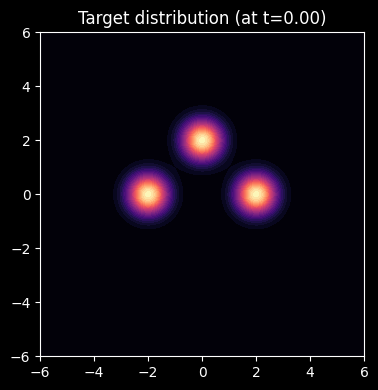

In [8]:
visualize_distribution(reverse_state['params'], t=0.0)

params = mixture_params_from_widgets(n_blobs.value,
                                     [m.value for m in means_x],
                                     [m.value for m in means_y],
                                     [s.value for s in stds])

target_dist = make_torch_mixture(params, t=0.0, device="cpu")
samples = target_dist.sample((50000,))

### Now let's train our score-based diffusion model using samples from the target distribution. It will use DSM to minimize the loss function until it converges. You can play around with some of the hyperparameters of the model below (see what happens when you change the learning rate, batch size, number of epochs, etc). This should take about 4 minutes.

**NOTE: The learned model parameters are saved after you're done training. If you run this cell again, it will pick up where you left off during this training. This will allow you to continue training without having to restart from epoch 0. BUT if you want to train a new model, you will either have to restart the kernel, or delete the saved checkpoint (which you can find in the $\texttt{models}$ folder).**

Using the Variance Exploding SDE


  0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/score_models/base.py:438: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  cost += float(loss)
Epoch 500 | Cost: 1.6e+00 |: 100%|██████████| 500/500 [04:22<00:00,  1.91it/s]

Finished training after 0.073 hours.


Text(0, 0.5, 'DSM loss')

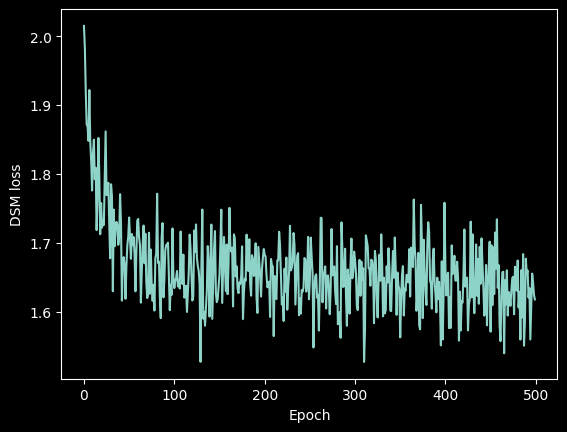

In [9]:
'''This section was adapted from the two_moons_demo.ipynb notebook by Alexandre Adam, (https://github.com/AlexandreAdam/score_models/blob/parallel/notebooks/two_moons_demo.ipynb)'''

from score_models import ScoreModel, MLP


dataset = Dataset(target_dist)

hyperparameters = {
    "dimensions": 2,
    "units": 50,
    "layers": 4,
    "time_embedding_dimensions": 50,
    "embedding_scale": 32,
    "activation": "swish",
    "time_branch_layers": 1,
    "bottleneck": 15,
    "attention": True
}

net = MLP(**hyperparameters).to(DEVICE)
model = ScoreModel(model=net, sigma_min=sigma_min, sigma_max=sigma_max)

learning_rate = 1e-2
batch_size = 256
epochs = 500
ema_decay = 0.99
checkpoints_directory = "models"
checkpoints = 10 # save a checkpoint every 10 epochs
models_to_keep = 1 # only keep one model, erase previous ones
seed = 42

# Fit the model to the dataset
losses = model.fit(
    dataset,
    learning_rate=learning_rate,
    batch_size=batch_size,
    epochs=epochs,
    ema_decay=ema_decay,
    checkpoints_directory=checkpoints_directory,
    checkpoints=checkpoints,
    models_to_keep=models_to_keep,
    seed=seed
    )
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("DSM loss")


In [14]:
from torch.func import vmap

# true_score uses the analytic mixture score implemented in torch

def true_score(t, x):
    return mixture_score(x, params, t)

score_out = widgets.Output()
t_mid_score = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, description='t_mid')


def update_score_plot(t_mid):
    with score_out:
        clear_output(wait=True)

        fig, axs = plt.subplots(2, 3, figsize=(14, 8))

        ts = [0.0, t_mid, 1.0]
        titles = [f't=0 (sigma_min)', f't={t_mid:.2f}', f't=1 (sigma_max)']
        scales = [1e3, 10 ** (3 - 2 * t_mid), 1e1]
        n = 40
        dx = 0.01
        xsize = 2

        for i, t in enumerate(ts):
            ax1 = vector_field(
                lambda x: model(torch.ones(n**2).to(DEVICE) * t, x).cpu(),
                xmin=-xsize, xmax=xsize, ymin=-xsize, ymax=xsize,
                n=n, dx=dx, scale=scales[i], ax=axs[0, i]
            )
            ax2 = vector_field(
                lambda x: true_score(torch.ones(n**2).to(DEVICE) * t, x).cpu(),
                xmin=-xsize, xmax=xsize, ymin=-xsize, ymax=xsize,
                n=n, dx=dx, scale=scales[i], ax=axs[1, i]
            )
            ax1.set_title(titles[i])

        axs[0, 0].set_ylabel(r"Score model")
        axs[1, 0].set_ylabel(r"True score")
        plt.tight_layout()
        plt.show()


display(widgets.VBox([t_mid_score, score_out]))

t_mid_score.observe(lambda change: update_score_plot(change['new']), names='value')

# Initial render
update_score_plot(t_mid_score.value)


### Great! Now let's sample from our trained score model using Euler-Murayama. This is integrated into the $\texttt{score-models}$ package, so we don't need to code the algorithm. Below, we'll compare samples from the true distribution to samples from the model. If you trained the model well enough, you should see that the samples from the model are indeed from the correct distribution!

Sampling from the prior | t = 0.0 | sigma = 1.1e-02| scale ~ 1.5e+00: 100%|██████████| 100/100 [00:17<00:00,  5.71it/s]


Text(0.5, 0, '$x_1$')

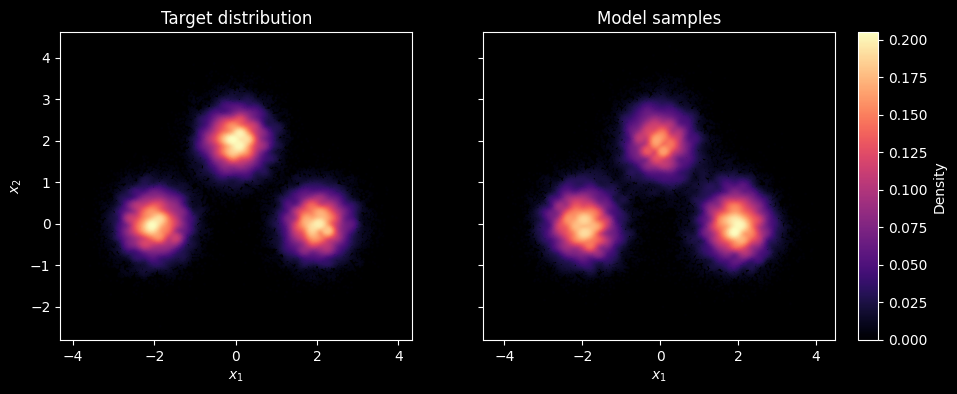

In [15]:

from scipy.interpolate import interpn


def density_scatter(points, fig=None, ax=None, sort=True, bins=40, cmap=COLORMAP, norm=None, ticks=None, colorbar=False, **kwargs):
    """
    Scatter plot colored by 2d histogram
    """
    x = points[:, 0]
    y = points[:, 1]
    if ax is None:
        fig, ax = plt.subplots()
    data, x_edges, y_edges = np.histogram2d(x, y, bins=bins, density=True)
    x_bins = 0.5 * (x_edges[1:] + x_edges[:-1])
    y_bins = 0.5 * (y_edges[1:] + y_edges[:-1])
    z = interpn((x_bins, y_bins), data, np.vstack([x, y]).T, method="splinef2d", bounds_error=False)
    z[np.where(np.isnan(z))] = 0.0
    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    if norm is None:
        norm = Normalize(vmin=z.min(), vmax=z.max())
    ax.scatter(x, y, c=z, cmap=cmap, norm=norm, **kwargs)
    if fig is not None:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        box = ax.get_position()
        cax = plt.axes([box.x0 * 1.01 + box.width * 1.05, box.y0, 0.02, box.height])
        fig.colorbar(sm, cax=cax, ticks=ticks)
        cax.set_ylabel('Density')
    return ax


N = 100  # Number of Euler-Maruyama steps
samples = model.sample(shape=[50000, 2], steps=N)

target_dist = make_torch_mixture(params, t=0.0, device="cpu")
x = target_dist.sample((50000,))

xmax = 2
ymax = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1 = density_scatter(x.cpu().numpy(), ax=ax1, s=1)
ax1.set_title("Target distribution")
ax1.set_ylabel(r"$x_2$")
ax1.set_xlabel(r"$x_1$")

ax2 = density_scatter(samples.cpu().numpy(), fig=fig, ax=ax2, s=1)
ax2.set_title("Model samples")
ax2.set_xlabel(r"$x_1$")
